# ZimaBlue — a tour

Everything the library does, in one pass: build a pool, put a cleaner in it,
make it dirty, run it, and then look at the result four different ways.

The argument the whole project is built around shows up in the *Coverage is not
cleanliness* section, and every number below is computed by this notebook
rather than quoted from the README.

```bash
pip install "zimablue[viz]"
```

In [1]:
%matplotlib inline

import os

import matplotlib.pyplot as plt
import numpy as np

import zimablue as zb

# Every run in this notebook is scaled by this. Two minutes keeps the tour
# quick; raise it to 20 or 30 to see controllers actually finish a pool.
MINUTES = float(os.environ.get("ZIMABLUE_TOUR_MINUTES", 6))

print("zimablue", zb.__version__, "·", MINUTES, "simulated minutes per run")

zimablue 0.1.0 · 8.0 simulated minutes per run


## Build a pool

A pool is a boundary polygon, a depth model, a surface material and a list of
features. The presets are just functions that assemble those four things.

In [2]:
pool = zb.make_pool("kidney")

print(pool)
print(f"  navigable floor  {pool.floor_area:6.1f} m2")
print(f"  wetted walls     {pool.wall_area:6.1f} m2")
print(f"  depth            {pool.max_depth:6.1f} m at the deepest point")
print(f"  presets          {', '.join(zb.POOL_PRESETS.names())}")

Pool(name='kidney', floor_area=54.8 m2, max_depth=2.00 m, features=4)
  navigable floor    54.8 m2
  wetted walls       48.2 m2
  depth               2.0 m at the deepest point
  presets          kidney, l_shaped, oval, rectangular, sloped, stairs


### Look at it

`zb.preview` renders the pool in the browser rather than through matplotlib:
**drag to rotate, scroll to zoom, shift-drag to pan, double-click to reset.**
No widget extensions and no kernel round trip, so it also survives being
exported to HTML.

Vertical scale is exaggerated 2.6× — a 12 m pool 2 m deep is otherwise a
pancake.

In [3]:
zb.preview(pool)

### Or build your own

Nothing about the presets is privileged. A Shapely polygon and a depth model
are the whole contract, and registering the result makes it available anywhere
a preset name is accepted — including `zimablue run` and scenario YAML.

In [4]:
from shapely.geometry import box as shapely_box

lap = zb.Pool(
    boundary=shapely_box(0, 0, 14, 6),
    depth=zb.PlaneSlopeDepth(
        shallow=0.9, deep=2.4, origin=(0.0, 0.0), direction=(1.0, 0.0), length=14.0
    ),
    name="lap_pool",
    material="tile",
    features=(
        zb.Obstacle("planter", polygon=shapely_box(8.0, 2.4, 9.2, 3.6), height=0.9),
        zb.Drain("main", position=(12.0, 3.0), radius=0.3, flow_rate=0.2),
        zb.Return("jet", position=(0.5, 3.0), direction=(1.0, 0.0)),
    ),
)
zb.POOL_PRESETS.add("lap_pool", lambda: lap)

zb.preview(lap)

## Add a cleaner

Cleaners are composed from components, not subclassed. Swapping a brush is
constructing a different `Brush`, not writing a `WideBrushCleaner`.

In [5]:
robot = zb.Cleaner(
    chassis=zb.Chassis(length=0.45, mass=10.5),
    cleaning=zb.CleaningSystem(
        brush=zb.Brush(width=0.38, aggressiveness=1.2),
        filter=zb.Filter(capacity=1200.0, mesh=45e-6),
    ),
    sensors=[zb.Encoder(), zb.IMU(), zb.Sonar(beam_angles=(0.0, 0.7, -0.7))],
)

print(robot)
print(f"  presets  {', '.join(zb.ROBOT_PRESETS.names())}")

Cleaner(name='cleaner', sensors=['encoder', 'imu', 'sonar'])
  presets  compact, heavy_duty, tracked


Sensors are imperfect on purpose, and breaking one is a first-class operation
rather than something you simulate by editing the model.

In [6]:
robot.sensors.sonar.inject_fault(
    bias=0.15,  # reads 15 cm long
    dropout_probability=0.02,  # loses 2% of pings
    start_time=120.0,  # ...starting two minutes in
)
print(robot.sensors.sonar)

Sonar(name='sonar', rate=20.0 Hz)


## Make it dirty

Dirt is a first-class spatial entity, not a scalar counter. Sediment and algae
live in continuous rasters; leaves and twigs are discrete items, some of them
too big for the intake to swallow.

Settling velocity comes from the Ferguson–Church equation rather than a table
of guesses, which is why the numbers below are checkable against the sediment
literature.

In [7]:
spec = zb.make_dirt("autumn")
state = spec.build(pool, np.random.default_rng(0))

print(f"total dirt   {state.total_mass:8.1f} g")
print(f"debris items {len(state.debris):8d}")
print()
print(f"{'type':<12}{'mass (g)':>10}{'grain (um)':>12}{'settling (mm/s)':>18}{'adhesion':>10}")
for name in state.field.layer_names():
    kind = state.field.types[name]
    mass = float(state.field.layers[name].sum())
    print(
        f"{name:<12}{mass:>10.1f}{kind.particle_size * 1e6:>12.0f}"
        f"{kind.settling_velocity * 1e3:>18.1f}{kind.adhesion:>10.2f}"
    )

total dirt      986.7 g
debris items       60

type          mass (g)  grain (um)   settling (mm/s)  adhesion
algae            274.0          15               0.0      0.85
sediment         493.3          20               0.1      0.10


## Run it

A simulation is a pool, a robot, some dirt, a controller and a seed. Same
version, platform, scenario and seed give a bit-identical recording.

In [8]:
result = zb.Simulation(
    pool="kidney", robot="tracked", dirt="autumn", controller="baseline_coverage", seed=42
).run(minutes=MINUTES)

print(result.metrics.summary())

  coverage            40.6 %   (walls 23 %)
  dirt removed        16.4 %   (165 g of 1002 g)
  uniformity          62.1 %
  revisits            0.60   extra passes/cell
  distance           105.0 m
  runtime              8.0 min
  energy               8.9 Wh   (battery 93 % left)
  collisions           113
  stuck                  0 events, 0.0 s
  termination       duration


### Where the dirt actually went

The scalar summary hides the geography. Spatial metrics keep it: which cells
were visited, how often, and how much dirt each still holds.

In [9]:
spatial = result.spatial
navigable = spatial.navigable
grid = pool.grid()  # the raster the metrics were computed on
cell_area = grid.cell_area

driven_over = navigable & (spatial.visits > 0)
threshold = 0.2 * spatial.initial_dirt.max()
still_dirty = driven_over & (spatial.remaining_dirt > threshold)

print(f"never visited            {(navigable & (spatial.visits == 0)).sum() * cell_area:6.1f} m2")
print(f"visited once             {(navigable & (spatial.visits == 1)).sum() * cell_area:6.1f} m2")
print(f"visited five times or more{(navigable & (spatial.visits >= 5)).sum() * cell_area:5.1f} m2")
print()
print(f"driven over but still dirty  {still_dirty.sum() * cell_area:6.1f} m2")
print("(suction alone does not lift adhered dirt -- it takes brush passes)")

never visited              32.6 m2
visited once               15.4 m2
visited five times or more  1.0 m2

driven over but still dirty     2.2 m2
(suction alone does not lift adhered dirt -- it takes brush passes)


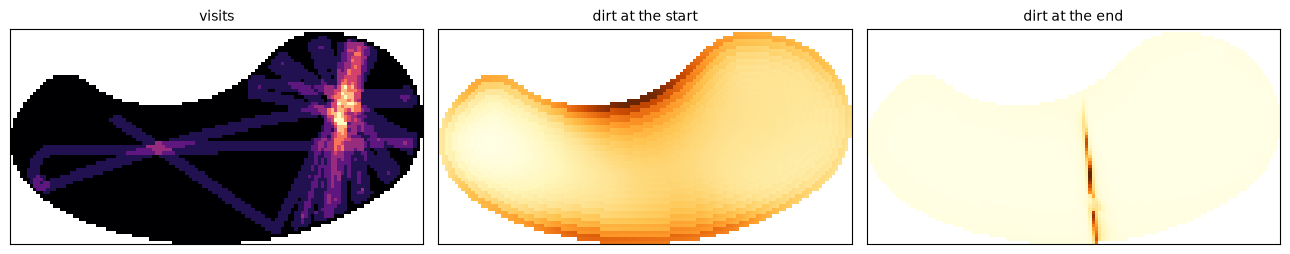

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
extent = grid.extent

for ax, (field, title, cmap) in zip(
    axes,
    [
        (np.where(navigable, spatial.visits, np.nan), "visits", "magma"),
        (np.where(navigable, spatial.initial_dirt, np.nan), "dirt at the start", "YlOrBr"),
        (np.where(navigable, spatial.remaining_dirt, np.nan), "dirt at the end", "YlOrBr"),
    ],
    strict=True,
):
    # Nearest, never bilinear: a blur here paints coverage the robot never had.
    ax.imshow(field, origin="lower", extent=extent, cmap=cmap, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()

## Coverage is not cleanliness

This is the whole thesis, and it is easiest to see by racing controllers whose
ranking *inverts* depending on which number you report.

`lawnmower_oracle` reads ground truth to drive a perfect path. It is
deliberately not deployable — it exists as an upper bound on coverage, and it
turns out to be a poor cleaner.

In [11]:
rows = []
for name in ["lawnmower_oracle", "random_bounce", "baseline_coverage", "systematic"]:
    # Ground truth is off unless you ask for it, and asking is the only way to
    # run the oracle at all -- so nobody reaches for it by accident.
    run = zb.Simulation(
        pool="kidney",
        dirt="autumn",
        controller=name,
        seed=42,
        expose_truth=(name == "lawnmower_oracle"),
    ).run(minutes=MINUTES)
    rows.append(
        (
            name,
            run.metrics.coverage,
            run.metrics.dirt_removed_fraction,
            run.metrics.distance_traveled,
        )
    )

print(f"{'controller':<20}{'coverage':>10}{'dirt removed':>14}{'distance':>11}")
for name, coverage, dirt, distance in rows:
    print(f"{name:<20}{coverage:>9.1%}{dirt:>14.1%}{distance:>10.0f} m")

best_coverage = max(rows, key=lambda r: r[1])[0]
best_cleaning = max(rows, key=lambda r: r[2])[0]
print()
print(f"best coverage: {best_coverage}   ·   best cleaning: {best_cleaning}")
print("Two different controllers -- which is the point. Report one number and you rank them wrong.")

controller            coverage  dirt removed   distance
lawnmower_oracle        61.3%         25.5%       124 m
random_bounce           48.4%         20.9%       105 m
baseline_coverage       40.6%         16.4%       105 m
systematic              39.4%         16.2%       109 m

best coverage: lawnmower_oracle   ·   best cleaning: lawnmower_oracle
Two different controllers -- which is the point. Report one number and you rank them wrong.


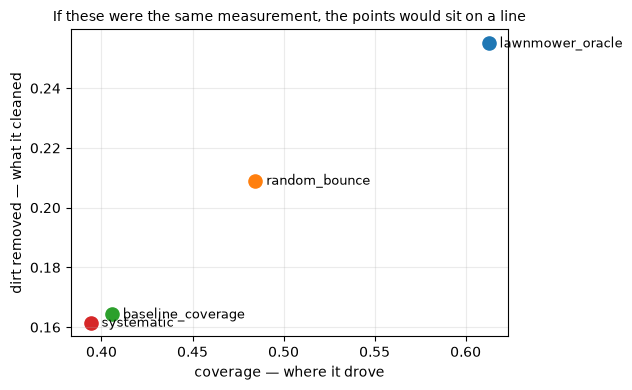

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
for name, coverage, dirt, _ in rows:
    ax.scatter(coverage, dirt, s=90)
    ax.annotate(name, (coverage, dirt), textcoords="offset points", xytext=(8, -3), fontsize=9)
ax.set_xlabel("coverage — where it drove")
ax.set_ylabel("dirt removed — what it cleaned")
ax.set_title("If these were the same measurement, the points would sit on a line", fontsize=10)
ax.grid(alpha=0.25)
fig.tight_layout()

## Watch it

A recording carries its own pool geometry and robot configuration, so it
replays from the file alone — no access to the code that produced it, and no
dependence on presets that may have changed since.

In [13]:
from pathlib import Path

path = result.save(Path("runs") / "tour.zbr")
recording = result.recording

print(recording.describe())

format          zbr v1
zimablue        0.1.0
scenario        adhoc
seed            42
pool            kidney
robot           tracked
dirt            autumn
controller      baseline_coverage
timestep        0.02 s
frames          24000 (8.0 min)
channels        42
events          165
dirt keyframes  49


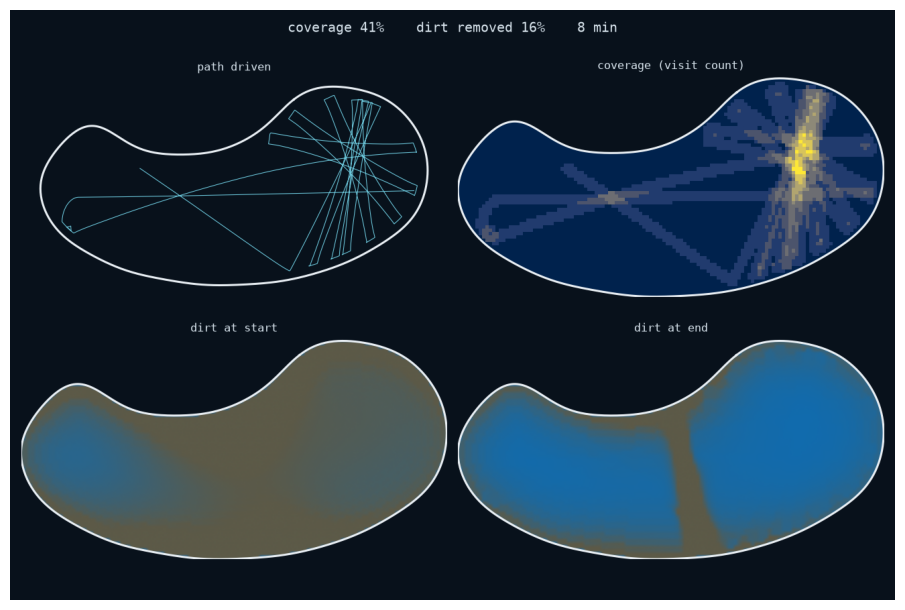

In [14]:
from zimablue.replay import export_summary

summary = export_summary(recording, "runs/tour_summary.png")

fig, ax = plt.subplots(figsize=(11, 6.2))
ax.imshow(plt.imread(summary))
ax.set_axis_off()
fig.tight_layout()

### The pool you just cleaned

Feeding the finished run back to `preview` tints the floor with the dirt that
was *left behind* and draws the path that was driven. Turning it over is the
fastest way to see why a corner scored badly.

In [15]:
zb.preview(result)

### In 3D

Rendered in three dimensions, not simulated in them: the motion still comes
from the 2D backend. What is genuinely 3D is the geometry — the floor is a
surface sampled from the depth model, so the robot sits deeper at the deep end
because the pool really is deeper there.

<Axes3D: title={'center': 'adhoc   08:00   21% of the dirt   105 m driven'}>

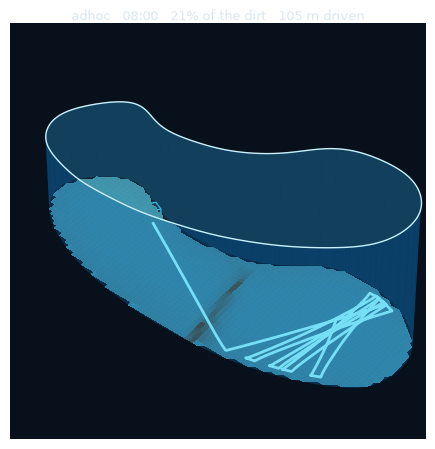

In [16]:
from zimablue.replay import render_3d

fig = plt.figure(figsize=(9, 5.4))
ax = fig.add_subplot(111, projection="3d")
render_3d(recording, recording.n_frames - 1, ax=ax)

### Dirt cam

Top-down replay is calming. From the cleaner's own bumper it is not: the camera
sits 18 cm off the floor and the pool turns out to be a silt plain with leaves
in it.

It is the same recording and the same dirt field, drawn by inverse perspective
mapping — one NumPy expression per frame over a grid of rays, no 3D engine
involved. The two views disagree constantly, and the disagreement is the point:
from above you see *where the robot went*, and from down here you see *what it
left behind*.

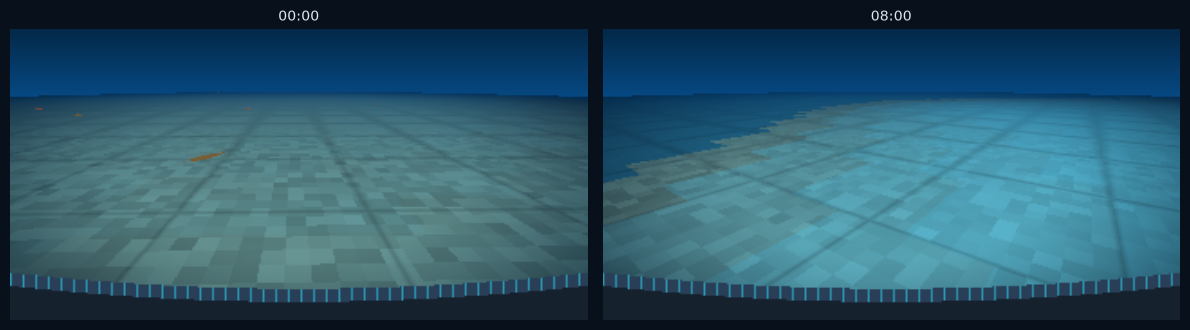

In [17]:
from zimablue.replay import DirtCam

cam = DirtCam(recording)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), facecolor="#08111b")
for ax, index in zip(axes, [0, recording.n_frames - 1], strict=True):
    seconds = float(recording.frames["time"][index])
    ax.imshow(cam.frame(index), interpolation="bilinear", aspect="auto")
    ax.set_title(f"{int(seconds // 60):02d}:{int(seconds % 60):02d}", color="#dbe7f0", fontsize=10)
    ax.set_axis_off()
fig.tight_layout()

Rendering the whole run as an animation, with the top-down panel beside it:

```python
from zimablue.replay import export_dirtcam
export_dirtcam(recording, "runs/tour_dirtcam.gif")
```

or from a shell, without opening Python at all:

```bash
zimablue replay runs/tour.zbr --dirtcam --gif dirtcam.gif
```

## Estimate it

The `systematic` controller does not get told where it is. It runs an EKF over
position, heading and **gyro bias**, and builds an occupancy map from sonar as
it goes.

Gyro bias is only observable when the robot stops — a stationary gyro's reading
*is* its bias — so zero-velocity updates are what keep heading from fanning out
over half an hour. The plot below is the price of having no absolute reference.

gyro bias settled at +0.51 deg/s


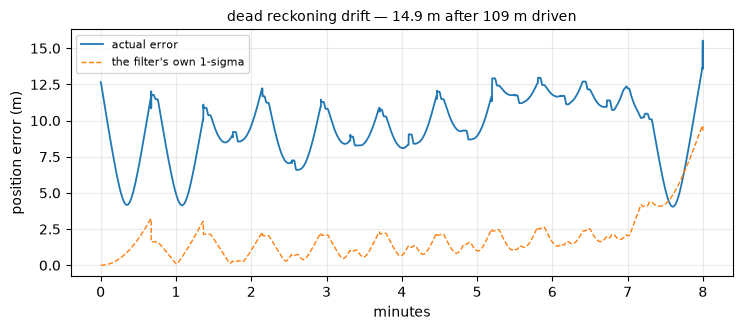

In [18]:
estimated = zb.Simulation(pool="kidney", dirt="autumn", controller="systematic", seed=42).run(
    minutes=MINUTES
)

# A controller can publish channels of its own; they land under "ctl.".
frames = estimated.recording.frames
error = np.hypot(frames["ctl.est_x"] - frames["x"], frames["ctl.est_y"] - frames["y"])
sigma = frames["ctl.est_sigma"]

fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.plot(frames["time"] / 60.0, error, linewidth=1.3, label="actual error")
ax.plot(
    frames["time"] / 60.0, sigma, linewidth=1.0, linestyle="--", label="the filter's own 1-sigma"
)
ax.set_xlabel("minutes")
ax.set_ylabel("position error (m)")
ax.set_title(
    f"dead reckoning drift — {error[-1]:.1f} m after {frames['distance'][-1]:.0f} m driven",
    fontsize=10,
)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()

print(f"gyro bias settled at {np.degrees(frames['ctl.est_bias'][-1]):+.2f} deg/s")

## Scale it

One run tells you what happened once. A controller that scores 80% on seed 42
and 45% on seed 43 has not been measured, it has been sampled — so the useful
unit of evidence is a batch and the useful output is a spread.

In [19]:
from zimablue.batch import run_batch

scenario = zb.load_scenario("kidney")
scenario.duration = MINUTES * 60.0

batch = run_batch(scenario, episodes=8)
print(batch.summary())

coverage = batch.values("coverage")
print()
print(
    f"coverage ranged {min(coverage):.1%} to {max(coverage):.1%}"
    f"  (spread {max(coverage) - min(coverage):.1%})"
)
print(
    f"the worst episode was seed {batch.worst('coverage', count=1)[0].seed}"
    " -- re-runnable exactly, from the seed alone"
)

episodes           8
success_rate       100.0 %
mean_coverage      44.7 %  (sd 2.7, min 40.6, max 48.4)
mean_dirt_removed  25.8 %  (sd 7.2, min 18.4, max 40.3)
mean_runtime       8.0 min
mean_energy        8.9 Wh
stuck_rate         0.0 %
mean_collisions    114
worst_episode      seed 42 (40.6 % coverage)

coverage ranged 40.6% to 48.4%  (spread 7.9%)
the worst episode was seed 42 -- re-runnable exactly, from the seed alone


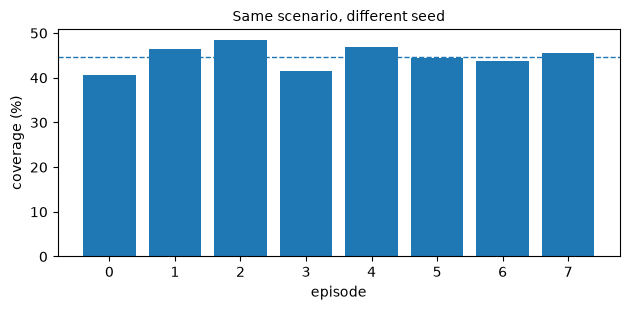

In [20]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.bar(range(len(coverage)), [c * 100 for c in coverage])
ax.axhline(np.mean(coverage) * 100, linestyle="--", linewidth=1)
ax.set_xlabel("episode")
ax.set_ylabel("coverage (%)")
ax.set_title("Same scenario, different seed", fontsize=10)
fig.tight_layout()

## Extend it

A controller is a class with `reset` and `step`. It sees sensor readings, never
ground truth, and registering it makes it usable from scenario YAML and the CLI
like any built-in.

In [21]:
class WallFollower:
    """Hug the right-hand wall at a fixed standoff, using sonar alone."""

    name = "wall_follower"
    STANDOFF = 0.5  # metres of clear floor between the hull and the wall
    CLEARANCE = 0.7  # metres ahead before committing to a turn

    def reset(self, robot):
        self.top = robot.locomotion.max_speed
        self.turning_until = 0.0

    def step(self, control_input):
        # Sensor readings, the clock, and the robot's own spec. There is no
        # pose in here, which is the whole point of the interface.
        sonar = control_input.reading("sonar")
        contact = control_input.reading("contact")
        bumped = bool(contact and contact.valid and np.any(contact.values > 0.5))

        if bumped:
            self.turning_until = control_input.time + 1.0
        if control_input.time < self.turning_until:
            return zb.DriveCommand(left=-self.top * 0.5, right=self.top * 0.5, brush=1.0, pump=1.0)

        if sonar is None or not sonar.valid:
            # A dropped ping is not an emergency: hold course.
            return zb.DriveCommand(left=self.top * 0.6, right=self.top * 0.6, brush=1.0, pump=1.0)

        ahead, _left, right = (float(v) for v in sonar.values[:3])
        if ahead < self.CLEARANCE:
            return zb.DriveCommand(left=-self.top * 0.4, right=self.top * 0.4, brush=1.0, pump=1.0)

        # The side beam sits 40 degrees off the bow, so its range is a slant,
        # not a standoff. Steering on the raw range holds the robot at
        # 0.64 x the distance you asked for -- which is close enough to scrape.
        beam = control_input.robot.sensors.sonar.beam_angles[2]
        standoff = right * abs(np.sin(beam))

        turn = float(np.clip((self.STANDOFF - standoff) * 1.2, -0.45, 0.45))
        speed = self.top * 0.55
        return zb.DriveCommand(
            left=speed * (1 - turn), right=speed * (1 + turn), brush=1.0, pump=1.0
        )


zb.CONTROLLERS.add("wall_follower", WallFollower)

follower = zb.Simulation(pool="kidney", dirt="autumn", controller="wall_follower", seed=42).run(
    minutes=MINUTES
)
print(follower.metrics.summary())

  coverage            18.7 %   (walls 8 %)
  dirt removed        17.1 %   (172 g of 1002 g)
  uniformity          64.1 %
  revisits            1.73   extra passes/cell
  distance            81.4 m
  runtime              8.0 min
  energy               8.6 Wh   (battery 93 % left)
  collisions             0
  stuck                  0 events, 0.0 s
  termination       duration


Note what it bought: a wall follower reaches the perimeter and nothing else, so
it scores poorly on coverage while collecting almost no collisions. That is a
real trade-off in a real product, and it is the kind of thing you want a
testbed to make legible rather than a demo video to hide.

## Determinism

The claim, checked rather than asserted: same version, same platform, same
scenario, same seed gives a bit-identical run.

In [22]:
a = zb.Simulation(pool="kidney", dirt="autumn", seed=7, record=False).run(minutes=1)
b = zb.Simulation(pool="kidney", dirt="autumn", seed=7, record=False).run(minutes=1)
c = zb.Simulation(pool="kidney", dirt="autumn", seed=8, record=False).run(minutes=1)

print(f"seed 7 twice:  coverage {a.metrics.coverage:.10%} vs {b.metrics.coverage:.10%}")
print(f"seed 8:        coverage {c.metrics.coverage:.10%}")
assert a.metrics.coverage == b.metrics.coverage, "determinism contract violated"
assert a.metrics.coverage != c.metrics.coverage, "the seed should change the outcome"
print("\nidentical on the same seed, different on another")

seed 7 twice:  coverage 8.6964448496% vs 8.6964448496%
seed 8:        coverage 8.7511394713%

identical on the same seed, different on another


## Where to go next

| | |
|---|---|
| [Getting started](../docs/getting-started.md) | Install, first run, common tasks |
| [Architecture](../docs/architecture.md) | Layering, backends, determinism contract |
| [Research](../docs/research.md) | Prior art, and which decision each finding drove |
| [Scenarios](../docs/scenarios.md) | YAML experiments and batch sweeps |
| [Recording](../docs/recording.md) | The `.zbr` format, channel by channel |
| [Replay](../docs/replay.md) | Controls, exporters, rendering notes |
| [Roadmap](../docs/roadmap.md) | Done, next, and deliberately not planned |

The scripts in `examples/` cover the same ground one topic at a time, and each
takes `--minutes` if you want a shorter run.